          x           y
0  3.834874  420.200907
1  3.899983  417.981901
2  3.966257  415.801855
3  4.033716  413.659699
4  4.102381  411.554383


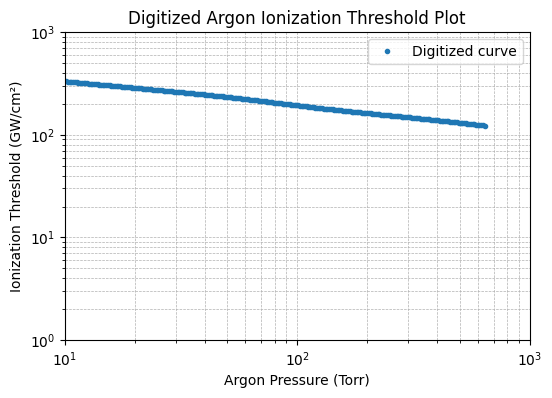

In [7]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load your CSV
# Replace with your actual CSV file path
csv_file = "Ar_ionization_loglog_digitized.csv"
df = pd.read_csv(csv_file)

# Step 3: Quick check of data
print(df.head())

# Step 4: Create a log–log plot
plt.figure(figsize=(6, 4))

x_torr = df['x']
I_GW = df['y']
plt.loglog(x_torr, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Torr)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()


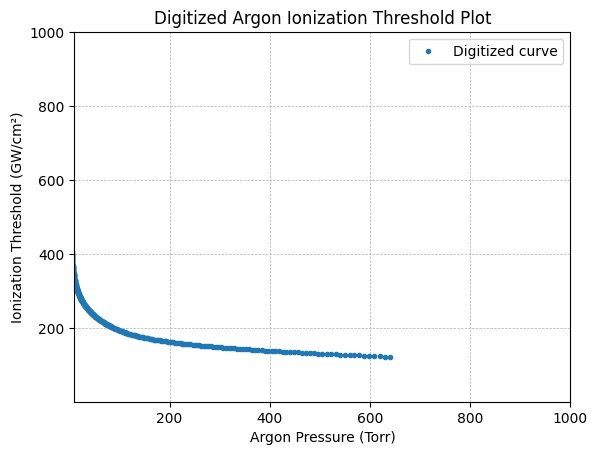

In [8]:
plt.plot(x_torr, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Torr)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()

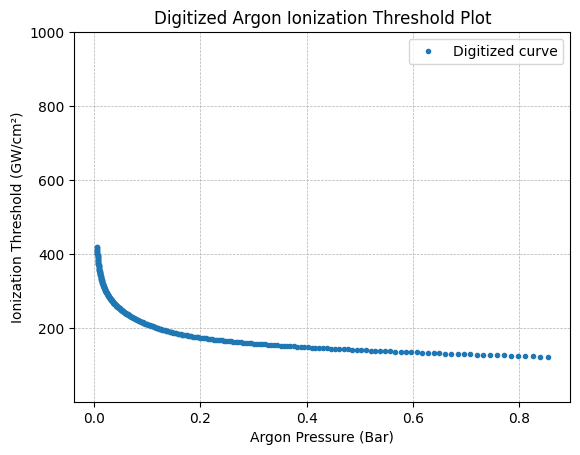

In [11]:
torr_to_bar = 1.33322e-3 #conversion factor from torr to bar
x_bar = x_torr * torr_to_bar

plt.plot(x_bar, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Bar)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
#plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()

B = -0.2384 ± 0.0010 (95% CI)
I_ref @ P_ref=1 bar = 119.783 GW/cm^2 [119.426, 120.142] (95% CI)
R^2 (log-space) = 0.9987


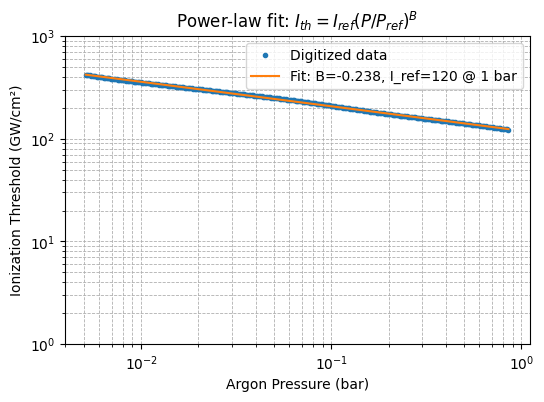

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input data (you already have these) ---
# x_bar: pressure in bar
# I_GW: ionization threshold in GW/cm^2

# --- Choose your reference pressure ---
P_ref = 1.0  # bar (change if you prefer another reference)

# --- Clean data: keep only finite, positive values ---
mask = np.isfinite(x_bar) & np.isfinite(I_GW) & (x_bar > 0) & (I_GW > 0)
P = np.asarray(x_bar[mask], dtype=float)
I = np.asarray(I_GW[mask], dtype=float)

# --- Fit in log space: log(I) = A + B*log(P) ---
logP = np.log(P)
logI = np.log(I)

# polyfit returns [slope, intercept] for degree=1
[B, A], cov = np.polyfit(logP, logI, 1, cov=True)
se_B = np.sqrt(cov[0, 0])
se_A = np.sqrt(cov[1, 1])

# Convert to your parameterization with P_ref
# I_ref = exp(A + B*log(P_ref))
log_Iref = A + B * np.log(P_ref)
I_ref = np.exp(log_Iref)

# Uncertainty on I_ref via error propagation in log space
# var(log I_ref) = var(A) + (log P_ref)^2 var(B) + 2*(log P_ref)*cov_AB
var_log_Iref = cov[1,1] + (np.log(P_ref)**2) * cov[0,0] + 2*np.log(P_ref)*cov[0,1]
se_log_Iref = np.sqrt(var_log_Iref)
# 95% CI (approx. normal in log space)
I_ref_lo = np.exp(log_Iref - 1.96*se_log_Iref)
I_ref_hi = np.exp(log_Iref + 1.96*se_log_Iref)

# Goodness of fit (R^2 in log space)
logI_pred = A + B*logP
ss_res = np.sum((logI - logI_pred)**2)
ss_tot = np.sum((logI - np.mean(logI))**2)
R2 = 1 - ss_res/ss_tot

print(f"B = {B:.4f} ± {1.96*se_B:.4f} (95% CI)")
print(f"I_ref @ P_ref={P_ref:g} bar = {I_ref:.6g} GW/cm^2 "
      f"[{I_ref_lo:.6g}, {I_ref_hi:.6g}] (95% CI)")
print(f"R^2 (log-space) = {R2:.4f}")

# --- Helper: model function ---
def I_th(P):
    return I_ref * (P / P_ref)**B

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,4))
ax.loglog(P, I, '.', label="Digitized data")

P_fit = np.logspace(np.log10(P.min()), np.log10(P.max()), 400)
ax.loglog(P_fit, I_th(P_fit),
          '-', label=f"Fit: B={B:.3f}, I_ref={I_ref:.3g} @ {P_ref:g} bar")

ax.set_xlabel("Argon Pressure (bar)")
ax.set_ylabel("Ionization Threshold (GW/cm²)")
ax.set_title("Power-law fit: $I_{th}=I_{ref}(P/P_{ref})^B$")
ax.grid(True, which="both", ls="--", lw=0.6)
ax.legend()
plt.ylim(1, 1000)  # keep your y-limits if you like
plt.show()
